In [17]:
# Import shared data processing functions
import sys
import os
from pathlib import Path
import pickle

# Add the parent directory to the Python path
sys.path.append(str(Path.cwd().parent))


# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# For data modeling
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# For saving models
import pickle


from data_utils import load_encoded_data, prepare_modeling_data


In [18]:

# Build the path to your data folder
BASE_DIR = Path(os.getcwd()).parent
DATA_PATH = BASE_DIR / "data" / "dataset.csv"
MODEL_PATH = BASE_DIR / "models"

In [19]:
# Load encoded data from previous steps
df_enc = load_encoded_data()
print(f"Encoded data shape: {df_enc.shape}")

# Prepare data for modeling (without outlier removal for tree-based models)
X, y = prepare_modeling_data(df_enc, remove_outliers=False)
print(f"Modeling data shape - Features: {X.shape}, Target: {y.shape}")

# # df_enc = encoded_data (after handling categorical variables)
# df_enc = df1.copy()

# # Encode the `salary` column as an ordinal numeric category
# df_enc['salary'] = (
#     df_enc['salary'].astype('category')
#     .cat.set_categories(['low', 'medium', 'high'])
#     .cat.codes
# )

# # Dummy encode the `department` column
# df_enc = pd.get_dummies(df_enc, drop_first=False)

Loading raw data...
Raw data shape: (14999, 10)
Cleaning data...
Data shape after cleaning: (11991, 10)
Removed 3008 duplicate rows
Creating overworked feature...
Data shape after feature engineering: (11991, 9)
Encoding categorical variables...
Encoded data shape: (11991, 18)
Encoded data shape: (11991, 18)
Preparing data for modeling...
Features shape: (11991, 17), Target shape: (11991,)
Modeling data shape - Features: (11991, 17), Target: (11991,)


In [20]:
df_enc.head()

,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,salary,overworked,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.53,2,3,0,1,0,0,0,False,False,False,False,False,False,False,True,False,False
1,0.86,5,6,0,1,0,1,1,False,False,False,False,False,False,False,True,False,False
2,0.88,7,4,0,1,0,1,1,False,False,False,False,False,False,False,True,False,False
3,0.87,5,5,0,1,0,0,1,False,False,False,False,False,False,False,True,False,False
4,0.52,2,3,0,1,0,0,0,False,False,False,False,False,False,False,True,False,False


### Modeling Approach B: Tree-based Model
This approach covers implementation of Decision Tree and Random Forest.


In [21]:
# outcome variable
y = df_enc['left']
y.head()


0    1
1    1
2    1
3    1
4    1
Name: left, dtype: int64

In [22]:
# features variable 
X = df_enc.drop('left', axis=1)
X.head()


,last_evaluation,number_project,tenure,work_accident,promotion_last_5years,salary,overworked,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.53,2,3,0,0,0,0,False,False,False,False,False,False,False,True,False,False
1,0.86,5,6,0,0,1,1,False,False,False,False,False,False,False,True,False,False
2,0.88,7,4,0,0,1,1,False,False,False,False,False,False,False,True,False,False
3,0.87,5,5,0,0,0,1,False,False,False,False,False,False,False,True,False,False
4,0.52,2,3,0,0,0,0,False,False,False,False,False,False,False,True,False,False


In [ ]:
write_pickle(BASE_DIR / "data", X, 'X_features')

Split the data into training, validating, and testing sets.


In [23]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)


### Hyperparameter tuning


#### Decision tree - Round 1


Construct a decision tree model and set up cross-validated grid-search to exhuastively search for the best model parameters.


Fit the decision tree model to the training data.


In [24]:
# Instantiate model
tree = DecisionTreeClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6]
             }

# Change scoring from set to list
scoring = ['roc_auc', 'f1', 'precision', 'accuracy', 'recall']

# Instantiate GridSearch
tree1 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')


In [25]:
%%time
tree1.fit(X_train, y_train)


CPU times: total: 2.81 s
Wall time: 2.81 s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [4, 6, 8, None],
                         'min_samples_leaf': [2, 5, 1],
                         'min_samples_split': [2, 4, 6]},
             refit='roc_auc',
             scoring=['roc_auc', 'f1', 'precision', 'accuracy', 'recall'])

Identify the optimal values for the decision tree parameters.


In [26]:
# Check best parameters
tree1.best_params_


{'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 2}

In [27]:
# Check best AUC score on CV
tree1.best_score_


np.float64(0.9582637931116877)

This is a strong AUC score, which shows that this model can predict employees who will leave very well.

### Extracting all the scores from the grid search.


In [28]:
def make_results(model_name:str, model_object, metric:str):
  
    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'auc': 'mean_test_roc_auc',
                   'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy'
                  }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]
    
    # Extract Accuracy, precision, recall, and f1 score from that row
    auc = best_estimator_results.mean_test_roc_auc
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
  
    # Creating table of results
    table = pd.DataFrame()
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          'auc': [auc]
                        })
  
    return table


Use the function just defined to get all the scores from grid search.


In [29]:
# Get all CV scores
tree1_cv_results = make_results('decision tree cv', tree1, 'auc')
tree1_cv_results


,model,precision,recall,F1,accuracy,auc
0,decision tree cv,0.857651,0.900204,0.877844,0.958301,0.958264


All of these scores from the decision tree model are strong indicators of good model performance. 

 Since decision trees can be vulnerable to overfitting, and random forests avoid overfitting by incorporating multiple trees to make predictions. So, let us also try by implementing random forest


#### Random forest - Round 1


Constructing a random forest model and set up cross-validated grid-search to exhuastively search for the best model parameters.


In [30]:
# Instantiate model
rf = RandomForestClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }  

# scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Instantiate GridSearch
rf1 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')


Fit the random forest model to the training data.


In [31]:
%%time
rf1.fit(X_train, y_train) 


CPU times: total: 13min 44s
Wall time: 13min 50s


GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [3, 5, None], 'max_features': [1.0],
                         'max_samples': [0.7, 1.0],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [300, 500]},
             refit='roc_auc',
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

#### Defining functions to pickle the model and read in the model.


In [32]:
def write_pickle(model_path, model_object, model_name):
    
    
    file_path = model_path / f"{model_name}.pickle"
    
    with open(file_path, "wb") as f:
        pickle.dump(model_object, f)
  
   
write_pickle(MODEL_PATH, rf1, 'hr_rf1')


In [33]:
#Reading the pickle file
def read_pickle(model_dir: Path, model_name: str):
    # build the full filepath
    file_path = model_dir / f"{model_name}.pickle"
    with open(file_path, 'rb') as f:
        return pickle.load(f)
    
rf2 = read_pickle(MODEL_PATH, 'hr_rf1')


Identify the best AUC score achieved by the random forest model on the training set.


In [34]:
# Check best AUC score on CV
rf1.best_score_


np.float64(0.9648898300143844)

Identify the optimal values for the parameters of the random forest model.


In [35]:
# Check best params
rf1.best_params_


{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 1.0,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 300}

Collect the evaluation scores on the training set for the decision tree and random forest models.


In [36]:
# Get all CV scores
rf1_cv_results = make_results('random forest cv', rf1, 'auc')
print(tree1_cv_results)
print(rf1_cv_results)


              model  precision    recall        F1  accuracy       auc
0  decision tree cv   0.857651  0.900204  0.877844  0.958301  0.958264
              model  precision    recall        F1  accuracy      auc
0  random forest cv   0.866431  0.880763  0.873246  0.957634  0.96489


- The evaluation scores of the random forest model are better than those of the decision tree model, with the exception of recall (the recall score of the random forest model is approximately 0.001 lower, which is a negligible amount). 
- This indicates that the random forest model mostly outperforms the decision tree model.

### Evaluate the final model on the test set/unseen data.


Define a function that gets all the scores from a model's predictions.


In [37]:
def get_scores(model_name:str, model, X_test_data, y_test_data):
  

    preds = model.best_estimator_.predict(X_test_data)

    auc = roc_auc_score(y_test_data, preds)
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision], 
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy],
                          'AUC': [auc]
                         })
  
    return table


Now use the best performing model to predict on the test set.


In [38]:
# Get predictions on test data
rf1_test_scores = get_scores('random forest1 test', rf1, X_test, y_test)
rf1_test_scores


,model,precision,recall,f1,accuracy,AUC
0,random forest1 test,0.871154,0.909639,0.88998,0.962642,0.941419


- The test scores are very similar to the validation scores, which is good. This appears to be a strong model. 
- Since this test set was only used for this model, you can be more confident that your model's performance on this data is representative of how it will perform on new, unseeen data.


#### Decision tree - Round 2


In [39]:
# Instantiate model
tree = DecisionTreeClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6]
             }

# Assign a dictionary of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Instantiate GridSearch
tree2 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [40]:
%%time
tree2.fit(X_train, y_train)

CPU times: total: 3.02 s
Wall time: 3.06 s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [4, 6, 8, None],
                         'min_samples_leaf': [2, 5, 1],
                         'min_samples_split': [2, 4, 6]},
             refit='roc_auc',
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

In [70]:
# save to pickle 
write_pickle(MODEL_PATH, tree2, 'hr_dt_tuned')

In [41]:
# Check best params
tree2.best_params_

{'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 2}

In [42]:
# Check best AUC score on CV
tree2.best_score_

np.float64(0.9582637931116877)

This model performs very well, even without satisfaction levels and detailed hours worked data. 

Next, check the other scores.

In [43]:
# Get all CV scores
tree2_cv_results = make_results('decision tree2 cv', tree2, 'auc')
print(tree1_cv_results)
print(tree2_cv_results)

              model  precision    recall        F1  accuracy       auc
0  decision tree cv   0.857651  0.900204  0.877844  0.958301  0.958264
               model  precision    recall        F1  accuracy       auc
0  decision tree2 cv   0.857651  0.900204  0.877844  0.958301  0.958264


Some of the other scores fell. That's to be expected given fewer features were taken into account in this round of the model. Still, the scores are very good.

#### Random forest - Round 2


In [44]:
# Instantiate model
rf = RandomForestClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }  

# Assign a dictionary of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']


# Instantiate GridSearch
rf2 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [45]:
%%time
rf2.fit(X_train, y_train) # --> Wall time: 10min 5s

CPU times: total: 13min 40s
Wall time: 13min 56s


GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [3, 5, None], 'max_features': [1.0],
                         'max_samples': [0.7, 1.0],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [300, 500]},
             refit='roc_auc',
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

In [46]:
# Write pickle
write_pickle(MODEL_PATH, rf2, 'hr_rf2')

In [47]:
# Read in pickle
rf2 = read_pickle(MODEL_PATH, 'hr_rf2')

In [48]:
# Check best params
rf2.best_params_

{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 1.0,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 300}

In [49]:
# Check best params
rf2.best_estimator_

RandomForestClassifier(max_depth=5, max_features=1.0, max_samples=1.0,
                       min_samples_split=4, n_estimators=300, random_state=0)

In [50]:
import json 

#Serializing the best estimator
best_model_params = rf2.best_params_

def write_json(model_path, model_object, model_name):
    
    
    file_path = model_path / f"{model_name}.json"
    
    with open(file_path, "w") as f:
        json.dump(model_object, f, indent = 2)
    # return file_path

write_json(MODEL_PATH, best_model_params, 'hr_rf2_best_params')

In [51]:
# Check best AUC score on CV
rf2.best_score_

np.float64(0.9648898300143844)

In [52]:
# Get all CV scores
rf2_cv_results = make_results('random forest2 cv', rf2, 'auc')
print(tree2_cv_results)
print(rf2_cv_results)

               model  precision    recall        F1  accuracy       auc
0  decision tree2 cv   0.857651  0.900204  0.877844  0.958301  0.958264
               model  precision    recall        F1  accuracy      auc
0  random forest2 cv   0.866431  0.880763  0.873246  0.957634  0.96489


Again, the scores dropped slightly, but the random forest performs better than the decision tree if using AUC as the deciding metric. 

Score the champion model on the test set now.

In [53]:
# Get predictions on test data
rf2_test_scores = get_scores('random forest2 test', rf2, X_test, y_test)
rf2_test_scores

,model,precision,recall,f1,accuracy,AUC
0,random forest2 test,0.871154,0.909639,0.88998,0.962642,0.941419


#### This seems to be a stable, well-performing final model. 

Plot a confusion matrix to visualize how well it predicts on the test set.

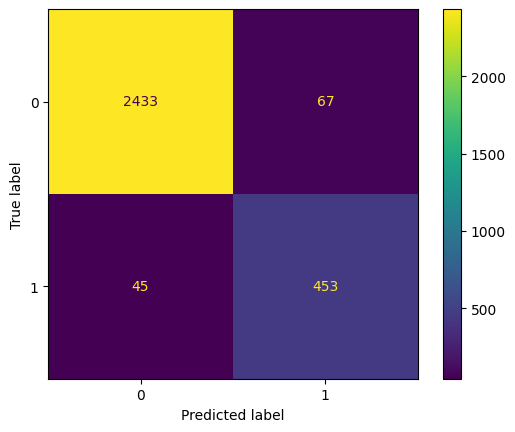

In [54]:
# Generate array of values for confusion matrix
preds = rf2.best_estimator_.predict(X_test)
cm = confusion_matrix(y_test, preds, labels=rf2.classes_)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=rf2.classes_)
disp.plot(values_format='')

The model predicts more false positives than false negatives, which means that some employees may be identified as at risk of quitting or getting fired, when that's actually not the case. But this is still a strong model.

For exploratory purpose, I am going to inspect the splits of the decision tree model and the most important features in the random forest model. 

#### Decision tree - Round 2


In [55]:
# Instantiate model
tree = DecisionTreeClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6]
             }

# Assign a dictionary of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Instantiate GridSearch
tree2 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [56]:
%%time
tree2.fit(X_train, y_train)

CPU times: total: 4.75 s
Wall time: 5.55 s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [4, 6, 8, None],
                         'min_samples_leaf': [2, 5, 1],
                         'min_samples_split': [2, 4, 6]},
             refit='roc_auc',
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

In [57]:
# Check best params
tree2.best_params_

{'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 2}

In [58]:
# Check best AUC score on CV
tree2.best_score_

np.float64(0.9582637931116877)

This model performs very well, even without satisfaction levels and detailed hours worked data. 

Next, check the other scores.

In [59]:
# Get all CV scores
tree2_cv_results = make_results('decision tree2 cv', tree2, 'auc')
print(tree1_cv_results)
print(tree2_cv_results)

              model  precision    recall        F1  accuracy       auc
0  decision tree cv   0.857651  0.900204  0.877844  0.958301  0.958264
               model  precision    recall        F1  accuracy       auc
0  decision tree2 cv   0.857651  0.900204  0.877844  0.958301  0.958264


Some of the other scores fell. That's to be expected given fewer features were taken into account in this round of the model. Still, the scores are very good.

#### Random forest - Round 2


In [60]:
# Instantiate model
rf = RandomForestClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }  

# Assign a dictionary of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']


# Instantiate GridSearch
rf2 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [ ]:
%%time
rf2.fit(X_train, y_train) # --> Wall time: 10min 5s

In [ ]:
# Write pickle
write_pickle(MODEL_PATH, rf2, 'hr_rf2')

In [62]:
# Read in pickle
rf2 = read_pickle(MODEL_PATH, 'hr_rf2')

In [63]:
# Check best params
rf2.best_params_

{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 1.0,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 300}

In [64]:
# Check best params
rf2.best_estimator_

RandomForestClassifier(max_depth=5, max_features=1.0, max_samples=1.0,
                       min_samples_split=4, n_estimators=300, random_state=0)

In [65]:
import json 

#Serializing the best estimator
best_model_params = rf2.best_params_

def write_json(model_path, model_object, model_name):
    
    
    file_path = model_path / f"{model_name}.json"
    
    with open(file_path, "w") as f:
        json.dump(model_object, f, indent = 2)
    # return file_path

write_json(MODEL_PATH, best_model_params, 'hr_rf2_best_params')

In [66]:
# Check best AUC score on CV
rf2.best_score_

np.float64(0.9648898300143844)

In [67]:
# Get all CV scores
rf2_cv_results = make_results('random forest2 cv', rf2, 'auc')
print(tree2_cv_results)
print(rf2_cv_results)

               model  precision    recall        F1  accuracy       auc
0  decision tree2 cv   0.857651  0.900204  0.877844  0.958301  0.958264
               model  precision    recall        F1  accuracy      auc
0  random forest2 cv   0.866431  0.880763  0.873246  0.957634  0.96489


Again, the scores dropped slightly, but the random forest performs better than the decision tree if using AUC as the deciding metric. 

Score the champion model on the test set now.

In [68]:
# Get predictions on test data
rf2_test_scores = get_scores('random forest2 test', rf2, X_test, y_test)
rf2_test_scores

,model,precision,recall,f1,accuracy,AUC
0,random forest2 test,0.871154,0.909639,0.88998,0.962642,0.941419


#### This seems to be a stable, well-performing final model. 

Plot a confusion matrix to visualize how well it predicts on the test set.

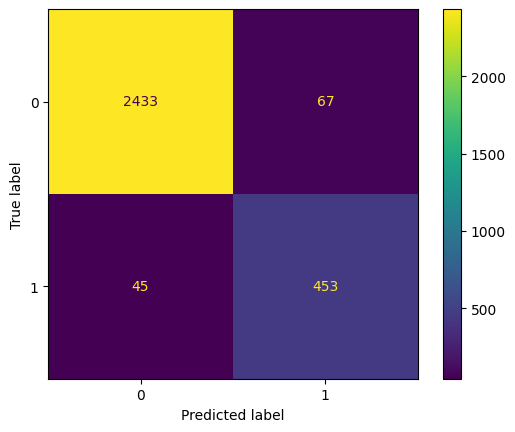

In [69]:
# Generate array of values for confusion matrix
preds = rf2.best_estimator_.predict(X_test)
cm = confusion_matrix(y_test, preds, labels=rf2.classes_)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=rf2.classes_)
disp.plot(values_format='')

The model predicts more false positives than false negatives, which means that some employees may be identified as at risk of quitting or getting fired, when that's actually not the case. But this is still a strong model.

For exploratory purpose, I am going to inspect the splits of the decision tree model and the most important features in the random forest model. 